<a href="https://colab.research.google.com/github/ShivamGupta-Projects/Credit_card_fraud_project/blob/main/Healthcare_Insurance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importing libraries for data and plots.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Uploading files in google colab.
from google.colab import files
uploaded = files.upload()

Saving Hospitalisation_details.csv to Hospitalisation_details.csv
Saving Medical_Examinations.csv to Medical_Examinations.csv
Saving Names.xlsx to Names.xlsx


In [4]:
# Loading all datasets.
df = pd.read_csv('Hospitalisation_details.csv')
df1 = pd.read_csv('Medical_Examinations.csv')
df2 = pd.read_excel('Names.xlsx')

In [5]:
# Merging all datasets into one dataframe.
df = df.merge(df1, on='Customer_ID')
df = df.merge(df2, on='Customer_ID')
df.head()

,Customer_ID,year,month,date,children,charges,Hospital_tier,City_tier,State_ID,BMI,HBA1C,Heart_Issues,Any_Transplants,Cancer_history,NumberOfMajorSurgeries,smoker,name
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,R1013,17.58,4.51,No,No,No,1,No,"German, Mr. Aaron K"
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,R1013,17.60,4.39,No,No,No,1,No,"Rosendahl, Mr. Evan P"
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,R1013,16.47,6.35,No,No,Yes,1,No,"Albano, Ms. Julie"
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,R1013,17.70,6.28,No,No,No,1,No,"Riveros Gonzalez, Mr. Juan D. Sr."
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,R1013,22.34,5.57,No,No,No,1,No,"Brietzke, Mr. Jordan"


In [6]:
# Checking rows and columns.
df.shape

(2335, 17)

In [7]:
# Checking for null values.
df.isna().sum()

,0
Customer_ID,0
year,0
month,0
date,0
children,0
charges,0
Hospital_tier,0
City_tier,0
State_ID,0
BMI,0


In [9]:
# Finding percentage of '?' values.
percentage = (df=='?').any(axis=1).mean()*100
percentage

np.float64(0.4282655246252677)

In [10]:
# Removing rows with '?' values.
df = df[~(df=='?').any(axis=1)]

In [11]:
# Checking unique states.
df['State_ID'].unique()

array(['R1013', 'R1012', 'R1011', 'R1015', 'R1019', 'R1016', 'R1018',
       'R1025', 'R1024', 'R1023', 'R1014', 'R1021', 'R1017', 'R1020',
       'R1026', 'R1022'], dtype=object)

In [12]:
# Grouping rare states into other.
important_states = ['R1011', 'R1012', 'R1013']

df['State_ID'] = df['State_ID'].where(df['State_ID'].isin(important_states),'Other')


In [13]:
# Creating dummy variables for state_id.
df = pd.get_dummies(df, columns=['State_ID'], drop_first=True)

In [16]:
# Checking unique values in surgeries.
df['NumberOfMajorSurgeries'].unique()

array([1, 0, 2, 3])

In [17]:
# Converting specified column into numbers.
df['NumberOfMajorSurgeries'] = df['NumberOfMajorSurgeries'].map(lambda x: 0 if x == 'No major surgery' else int(x))

In [18]:
df['NumberOfMajorSurgeries'].unique()

array([1, 0, 2, 3])

In [19]:
# Converting yes and no to 0 and 1 using mapping.
df['Any_Transplants'] = df['Any_Transplants'].map({'yes': 1, 'No': 0})
df['Cancer_history'] = df['Cancer_history'].map({'Yes': 1, 'No': 0})

In [20]:
# Setting up month and date.
df['day'] = df['date']
df['month'] = pd.to_datetime(df['month'], format='%b')
df['month'] = df['month'].dt.month

In [21]:
# Creating Date of birth column.
df['DOB'] = pd.to_datetime(df[['year','month','day']])

In [22]:
# Calculating age of patients.
today = pd.Timestamp('now')
df['Patient Age'] = ((today - df['DOB']).dt.days / 365.25).astype(int)

In [23]:
# Extracting gender from name titles.
df['Gender'] = df['name'].apply(lambda x: 'M' if 'Mr.' in x else 'F' if 'Ms.' in x else 'Other')

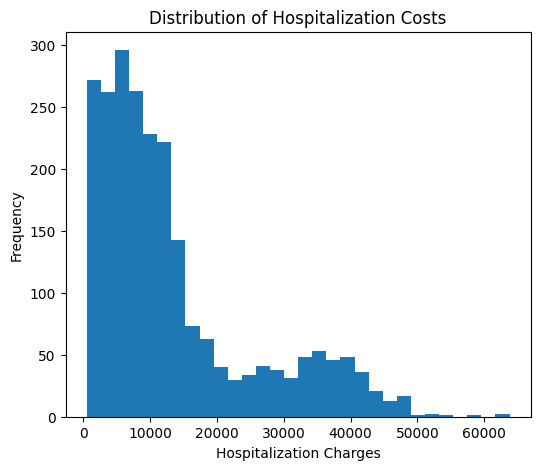

In [24]:
# Histogram for hospitalisation Charges.
plt.figure(figsize=(6,5))
plt.hist(df['charges'],bins=30)
plt.xlabel('Hospitalization Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Hospitalization Costs')
plt.show()


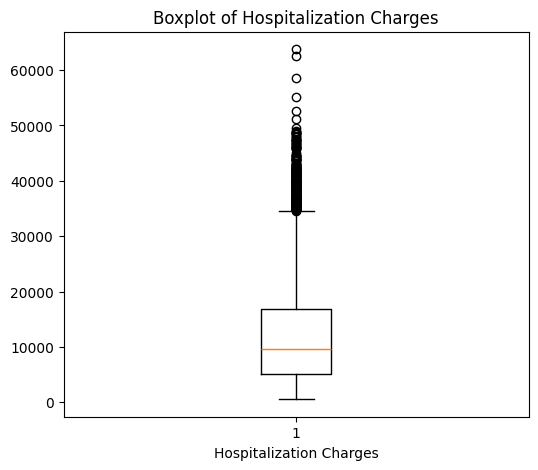

In [25]:
# Boxplot to see outliers in Charges.
plt.figure(figsize=(6,5))
plt.boxplot(df['charges'])
plt.xlabel('Hospitalization Charges')
plt.title('Boxplot of Hospitalization Charges')
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 43.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


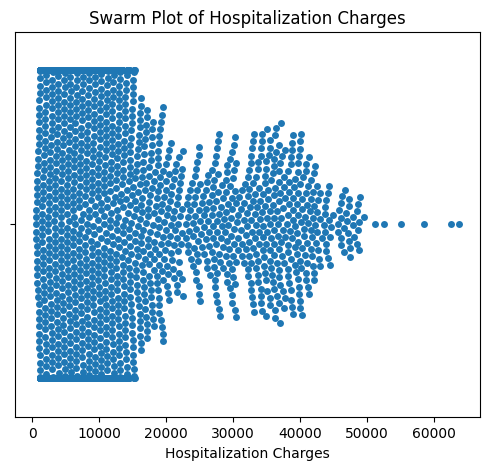

In [26]:
# Swarm plot for charges.
plt.figure(figsize=(6,5))
sns.swarmplot(x=df['charges'])
plt.xlabel('Hospitalization Charges')
plt.title('Swarm Plot of Hospitalization Charges')
plt.show()


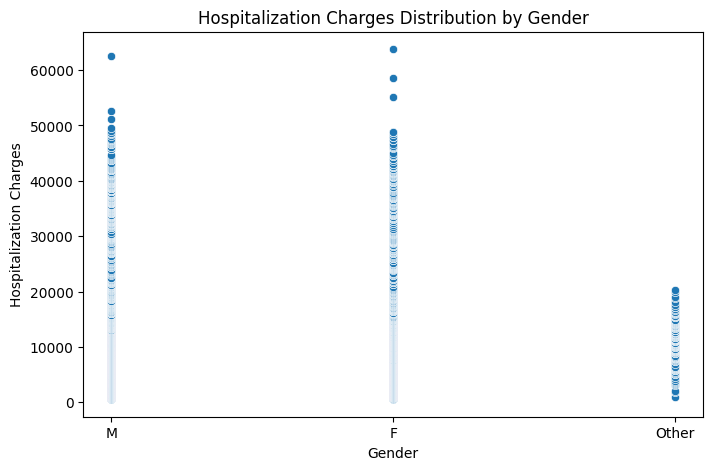

In [28]:
# Charges vs Gender scatter plot.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Gender', y='charges', data=df)
plt.title('Hospitalization Charges Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Hospitalization Charges')
plt.show()


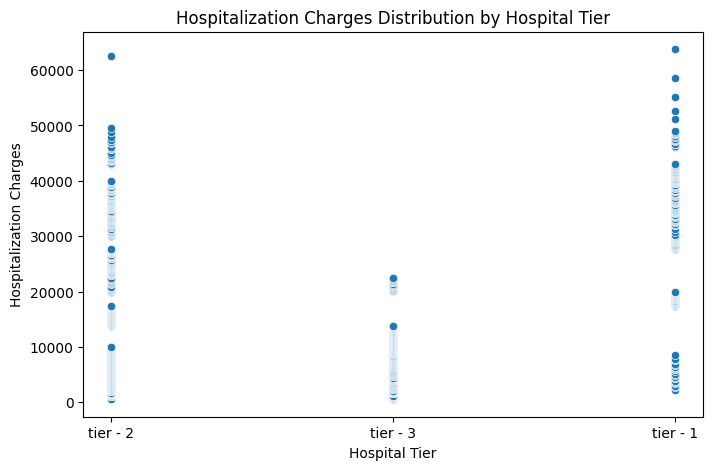

In [29]:
# Charges vs hospital tier scatter plot.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hospital_tier', y='charges', data=df)
plt.title('Hospitalization Charges Distribution by Hospital Tier')
plt.xlabel('Hospital Tier')
plt.ylabel('Hospitalization Charges')
plt.show()


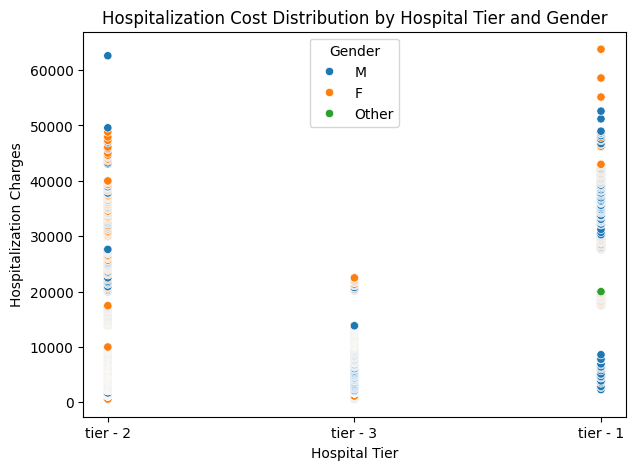

In [30]:
# Charges of hospitalisation cost via Hospital tier and Gender.
plt.figure(figsize=(7,5))
sns.scatterplot(x='Hospital_tier',y='charges',hue='Gender',data=df)
plt.title('Hospitalization Cost Distribution by Hospital Tier and Gender')
plt.xlabel('Hospital Tier')
plt.ylabel('Hospitalization Charges')
plt.show()


In [31]:
# Calculating median cost by per Hospital tier.
median_cost = df.groupby('Hospital_tier')['charges'].median().reset_index()
median_cost

,Hospital_tier,charges
0,tier - 1,32097.435
1,tier - 2,7168.760
2,tier - 3,10676.830


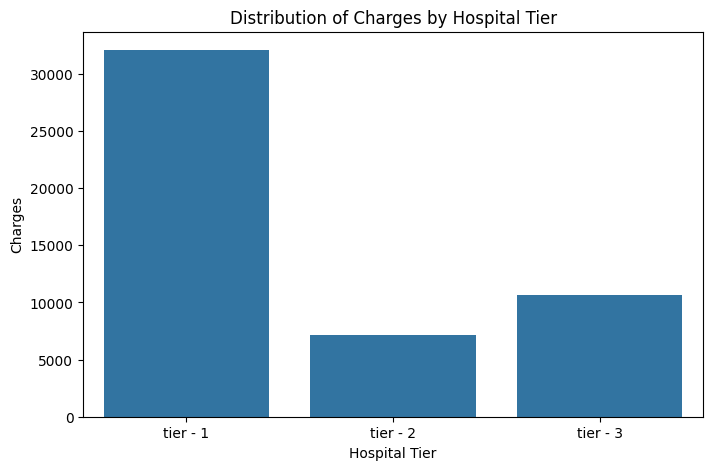

In [32]:
# Bar plot for median charges per Hospital tier.
plt.figure(figsize=(8, 5))
sns.barplot(x='Hospital_tier', y='charges', data=median_cost)
plt.xlabel('Hospital Tier')
plt.ylabel('Charges')
plt.title('Distribution of Charges by Hospital Tier')
plt.show()

In [34]:
# Count of people by city and hospital tier.
freq_table = df.groupby(['City_tier', 'Hospital_tier']).size().unstack().fillna(0)
freq_table

Hospital_tier,tier - 1,tier - 2,tier - 3
City_tier,,,
tier - 1,85,403,241
tier - 2,106,479,222
tier - 3,109,452,228


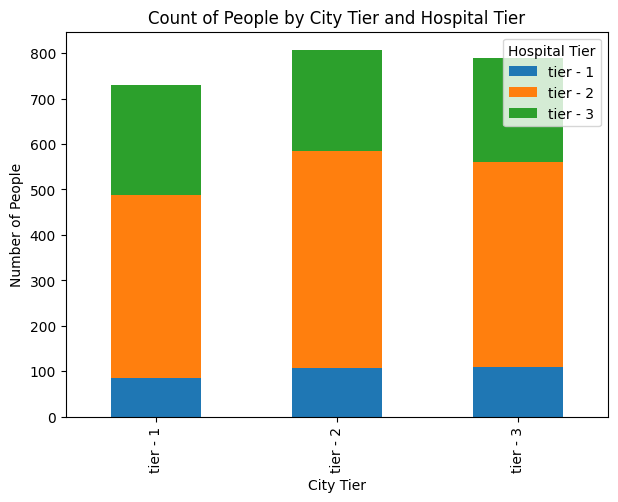

In [35]:
freq_table.plot(kind='bar',stacked=True,figsize=(7, 5))
plt.xlabel('City Tier')
plt.ylabel('Number of People')
plt.title('Count of People by City Tier and Hospital Tier')
plt.legend(title='Hospital Tier')
plt.show()

In [ ]:
df['Hospital_tier'].unique()

array(['tier - 2', 'tier - 3', 'tier - 1'], dtype=object)

In [36]:
# Mapping Hospital Tier to numbers.
df['Hospital_tier'] = df['Hospital_tier'].map({'tier - 1': 1, 'tier - 2': 2,'tier - 3':3})

In [38]:
hospital1_med = df[df['Hospital_tier']==1].charges.median()
hospital2_med = df[df['Hospital_tier']==2].charges.median()
hospital3_med = df[df['Hospital_tier']==3].charges.median()

In [39]:
# Using fried man test for statistics.
from scipy.stats import friedmanchisquare
stats,p = friedmanchisquare([hospital1_med],[hospital2_med],[hospital3_med])
stats,p
# p value is greater than 0.05 so we fail to reject the null hypotheses.
# the average hospitalization costs for three types of hospitals are not significantly different.

(np.float64(2.0), np.float64(0.36787944117144245))

In [ ]:
df['City_tier'].unique()

array(['tier - 3', 'tier - 1', 'tier - 2'], dtype=object)

In [ ]:
df['City_tier'] = df['City_tier'].map({'tier - 1': 1, 'tier - 2': 2,'tier - 3':3})

In [ ]:
city1 = df[df['City_tier']==1].charges.median()
city2 = df[df['City_tier']==2].charges.median()
city3 = df[df['City_tier']==3].charges.median()

In [ ]:
stats,p = friedmanchisquare([city1],[city2],[city3])
stats,p
# p value is greater than 0.05 we fail to reject the null hypotheses.

(np.float64(2.0), np.float64(0.36787944117144245))

In [40]:
# Mapping smoker to 1 and 0.
df['smoker'].unique()
df['smoker'] = df['smoker'].map({'yes':1,'Yes':1,'no':0,'No':0})

In [41]:
from scipy.stats import ttest_ind
smoker_cost = df[df['smoker'] == 1]['charges']
non_smoker_cost = df[df['smoker'] == 0]['charges']
t_stat, p = ttest_ind(smoker_cost, non_smoker_cost)
t_stat, p
# p value is less than 0.05 so we reject the null hypothesis.

(np.float64(74.15560699695726), np.float64(0.0))

In [42]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df['smoker'], df['Heart_Issues'])
chi2, p, dof, expected = chi2_contingency(table)

chi2, p

#p value is greater than 0.05 we fail to reject the null hypotheses.

(np.float64(0.08588150449910657), np.float64(0.7694797581780767))

Machine Leraning

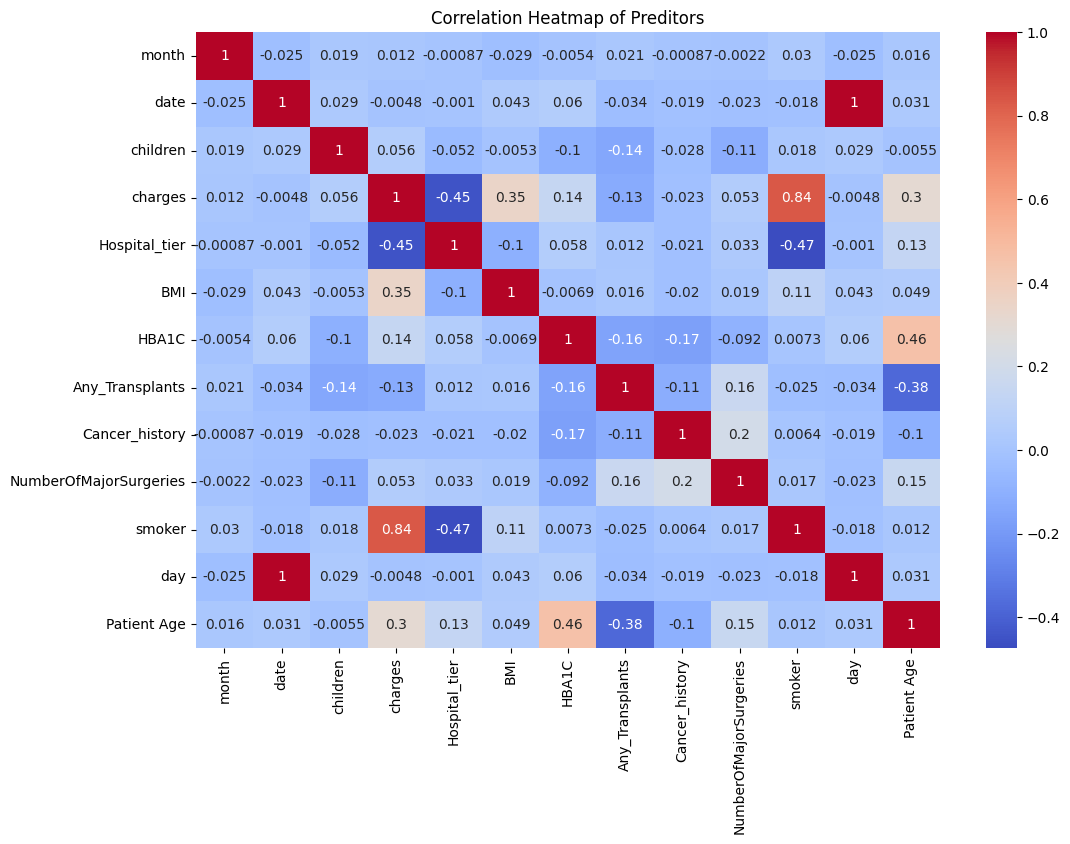

In [43]:
# Creating Heatmap to find out correlation between predictors to identify highly correlated predictors
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Preditors')
plt.show()

In [44]:
# Droping the unneccessary columns from the features data.
X = df.drop(['charges','Customer_ID','name','DOB'], axis=1)
X = X.select_dtypes(include=['int64','float64'])
y = df['charges']

In [45]:
# Swtting stratified k-fold.
from sklearn.model_selection import StratifiedKFold

y_bins = pd.qcut(y, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True)

In [46]:
# Running linear regression with pipeline.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rmse_scores = []

for train_idx, test_idx in skf.split(X, y_bins):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores.append(rmse)

np.mean(rmse_scores)

np.float64(4459.512946047478)

In [47]:
# Testing ridge regression model.
from sklearn.linear_model import Ridge

rmse_scores = []

for train_idx, test_idx in skf.split(X, y_bins):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores.append(rmse)

np.mean(rmse_scores)

np.float64(4478.516521947809)

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X, y)

importance = pd.Series(gbr.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
smoker,0.756639
BMI,0.114423
Patient Age,0.093759
Hospital_tier,0.022714
children,0.006883
HBA1C,0.003382
day,0.001087
date,0.000866
NumberOfMajorSurgeries,0.000160
Any_Transplants,0.000083


In [49]:
redundant_variables = importance[importance < 0.01]
redundant_variables

,0
date,0.000866
children,0.006883
HBA1C,0.003382
Any_Transplants,0.000083
Cancer_history,0.000003
NumberOfMajorSurgeries,0.000160
day,0.001087


In [51]:
# Predicting charges for a new patient.
new_patient = pd.DataFrame({
    'Age':[36],
    'HBA1c':[5.8],
    'children':[2],
    'smoker':[1],
    'Hospital_tier':[1],
    'City_tier':[1],
    'NumberOfMajorSurgeries':[0],
    'Any_Transplants':[0],
    'Cancer_history':[1]
})
new_patient = new_patient.reindex(columns=X.columns, fill_value=0)
gbr.predict(new_patient)

array([22463.63726474])

In [54]:
# Get the file ready to export in excel.
df.to_excel("Hospitalisation_data.xlsx", index=False)

In [55]:
# Saving and download the final file
from google.colab import files
files.download("Hospitalisation_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>